# Synthetic Graphs: k-BFS vs Takes-Kosters

Goal: generate synthetic graphs, compare diameter estimates and runtimes for k-BFS and Takes-Kosters, and visualize observations.

In [19]:
import math
import random
import time
import tracemalloc
from collections import deque
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append(str(Path().resolve()))

from algos.kbfs import kbfs_eccentricity_estimate
from algos.takeskosters import takes_kosters
from scripts.graph_io import build_graph_from_edges

In [20]:
random.seed(42)

def generate_erdos_renyi(vertex_count: int, p: float) -> object:
    if vertex_count <= 1:
        return build_graph_from_edges([])
    edges = []
    for u in range(vertex_count):
        for v in range(u + 1, vertex_count):
            if random.random() < p:
                edges.append((u, v))
    return build_graph_from_edges(edges)

def generate_sparse(vertex_count: int, p: float = 0.03) -> object:
    return generate_erdos_renyi(vertex_count, p)

def generate_dense(vertex_count: int, p: float = 0.6) -> object:
    return generate_erdos_renyi(vertex_count, p)

def generate_tree(vertex_count: int) -> object:
    edges = []
    for node in range(1, vertex_count):
        parent = random.randrange(node)
        edges.append((parent, node))
    return build_graph_from_edges(edges)

def generate_complete(vertex_count: int) -> object:
    edges = []
    for i in range(vertex_count):
        for j in range(i + 1, vertex_count):
            edges.append((i, j))
    return build_graph_from_edges(edges)

def generate_bipartite(vertex_count: int, p: float = 0.1) -> object:
    if vertex_count < 2:
        return build_graph_from_edges([])
    left_size = vertex_count // 2
    right_size = vertex_count - left_size
    left_nodes = list(range(left_size))
    right_nodes = list(range(left_size, vertex_count))
    edges = []
    for u in left_nodes:
        for v in right_nodes:
            if random.random() < p:
                edges.append((u, v))
    return build_graph_from_edges(edges)

def generate_path(vertex_count: int) -> object:
    edges = [(node, node + 1) for node in range(vertex_count - 1)]
    return build_graph_from_edges(edges)

def generate_grid(vertex_count: int, rows: int | None = None, cols: int | None = None) -> object:
    if rows is None or cols is None:
        side = max(1, int(math.sqrt(vertex_count)))
        rows = side
        cols = max(1, vertex_count // rows)
    edges = []
    def node_id(r: int, c: int) -> int:
        return r * cols + c
    for r in range(rows):
        for c in range(cols):
            if r + 1 < rows:
                edges.append((node_id(r, c), node_id(r + 1, c)))
            if c + 1 < cols:
                edges.append((node_id(r, c), node_id(r, c + 1)))
    return build_graph_from_edges(edges)

def generate_small_world(vertex_count: int, k: int = 4, p: float = 0.1) -> object:
    if vertex_count < 3:
        return build_graph_from_edges([])
    k = max(2, k)
    if k >= vertex_count:
        k = vertex_count - 1
    if k % 2 == 1:
        k += 1
    neighbors = {i: set() for i in range(vertex_count)}
    for i in range(vertex_count):
        for j in range(1, k // 2 + 1):
            v = (i + j) % vertex_count
            neighbors[i].add(v)
            neighbors[v].add(i)
    edges = set()
    for u in range(vertex_count):
        for v in neighbors[u]:
            if u < v:
                edges.add((u, v))
    edge_list = list(edges)
    for u, v in edge_list:
        if random.random() < p:
            neighbors[u].discard(v)
            neighbors[v].discard(u)
            candidates = [x for x in range(vertex_count) if x != u and x not in neighbors[u]]
            if candidates:
                new_v = random.choice(candidates)
                neighbors[u].add(new_v)
                neighbors[new_v].add(u)
    edges = []
    for u in range(vertex_count):
        for v in neighbors[u]:
            if u < v:
                edges.append((u, v))
    return build_graph_from_edges(edges)

def generate_scale_free(vertex_count: int, m: int = 2) -> object:
    if vertex_count <= m + 1:
        return generate_complete(vertex_count)
    edges = []
    for i in range(m + 1):
        for j in range(i + 1, m + 1):
            edges.append((i, j))
    degrees = [0] * vertex_count
    for u, v in edges:
        degrees[u] += 1
        degrees[v] += 1
    for new_node in range(m + 1, vertex_count):
        candidates = list(range(new_node))
        weights = [degrees[i] if degrees[i] > 0 else 1 for i in candidates]
        targets = set()
        while len(targets) < m:
            targets.add(random.choices(candidates, weights=weights, k=1)[0])
        for v in targets:
            edges.append((new_node, v))
            degrees[new_node] += 1
            degrees[v] += 1
    return build_graph_from_edges(edges)

GENERATOR_BY_TYPE = {
    "random_sparse": generate_sparse,
    "dense": generate_dense,
    "tree": generate_tree,
    "complete": generate_complete,
    "bipartite": generate_bipartite,
    "path": generate_path,
    "grid": generate_grid,
    "small_world": generate_small_world,
    "scale_free": generate_scale_free,
}

In [21]:
def count_edges(graph) -> int:
    return sum(len(neighbors) for neighbors in graph.adj) // 2

def exact_diameter(graph) -> int:
    if graph.V == 0:
        return 0
    diameter = 0
    for node in range(graph.V):
        distances = graph.bfs(node)
        finite = [d for d in distances if d >= 0]
        if finite:
            diameter = max(diameter, max(finite))
    return diameter

def bfs_with_counts(graph, start_node: int) -> tuple[list[int], int, int]:
    distances = [-1] * graph.V
    if start_node < 0 or start_node >= graph.V:
        return distances, 0, 0
    queue = deque([start_node])
    distances[start_node] = 0
    vertex_visits = 1
    edge_checks = 0
    while queue:
        u = queue.popleft()
        for v in graph.adj[u]:
            edge_checks += 1
            if distances[v] == -1:
                distances[v] = distances[u] + 1
                queue.append(v)
                vertex_visits += 1
    return distances, vertex_visits, edge_checks

def _multi_source_bit_bfs_stats(adj: list[list[int]], sources: list[int]) -> tuple[list[int], int, int]:
    vertex_count = len(adj)
    if vertex_count == 0:
        return [], 0, 0
    sources = list(dict.fromkeys(sources))
    if not sources:
        return [-1] * vertex_count, 0, 0
    visited_bits = [0] * vertex_count
    frontier_bits = [0] * vertex_count
    distances = [-1] * vertex_count
    vertex_visits = 0
    edge_checks = 0
    for idx, s in enumerate(sources):
        if s < 0 or s >= vertex_count:
            continue
        bit = 1 << idx
        if visited_bits[s] & bit:
            continue
        visited_bits[s] |= bit
        frontier_bits[s] |= bit
        distances[s] = 0
        vertex_visits += 1
    frontier = [v for v in range(vertex_count) if frontier_bits[v]]
    round_num = 0
    while frontier:
        round_num += 1
        next_bits = [0] * vertex_count
        for u in frontier:
            bits = frontier_bits[u]
            for v in adj[u]:
                edge_checks += 1
                next_bits[v] |= bits
        for u in frontier:
            frontier_bits[u] = 0
        new_frontier = []
        for v, bits in enumerate(next_bits):
            new_bits = bits & ~visited_bits[v]
            if new_bits:
                visited_bits[v] |= new_bits
                frontier_bits[v] = new_bits
                if round_num > distances[v]:
                    distances[v] = round_num
                new_frontier.append(v)
                vertex_visits += 1
        frontier = new_frontier
    return distances, vertex_visits, edge_checks

def kbfs_estimate_with_stats(adj: list[list[int]], k: int) -> tuple[list[int], dict]:
    vertex_count = len(adj)
    if vertex_count == 0:
        return [], {"bfs_passes": 0, "vertex_visits": 0, "edge_checks": 0, "pre_time": 0.0, "search_time": 0.0}
    if k <= 0:
        return [-1] * vertex_count, {"bfs_passes": 0, "vertex_visits": 0, "edge_checks": 0, "pre_time": 0.0, "search_time": 0.0}
    k = min(k, vertex_count)
    pre_start = time.perf_counter()
    sources_phase1 = random.sample(range(vertex_count), k)
    pre_time = time.perf_counter() - pre_start
    search_start = time.perf_counter()
    dist_phase1, v_visits_1, e_checks_1 = _multi_source_bit_bfs_stats(adj, sources_phase1)
    search_time = time.perf_counter() - search_start
    pre_start = time.perf_counter()
    ranked = sorted(range(vertex_count), key=lambda i: dist_phase1[i], reverse=True)
    sources_phase2 = ranked[:k]
    pre_time += time.perf_counter() - pre_start
    search_start = time.perf_counter()
    dist_phase2, v_visits_2, e_checks_2 = _multi_source_bit_bfs_stats(adj, sources_phase2)
    search_time += time.perf_counter() - search_start
    estimates = [max(dist_phase1[i], dist_phase2[i]) for i in range(vertex_count)]
    stats = {
        "bfs_passes": 2,
        "vertex_visits": v_visits_1 + v_visits_2,
        "edge_checks": e_checks_1 + e_checks_2,
        "pre_time": pre_time,
        "search_time": search_time,
    }
    return estimates, stats

def takes_kosters_with_stats(graph) -> tuple[int, dict]:
    if graph.V == 0:
        return 0, {"bfs_passes": 0, "vertex_visits": 0, "edge_checks": 0, "pre_time": 0.0, "search_time": 0.0, "iterations": 0}
    graph_diameter_lb = 0
    upper_bounds = [math.inf] * graph.V
    visited = [False] * graph.V
    visited_count = 0
    pre_time = 0.0
    search_time = 0.0
    bfs_passes = 0
    vertex_visits = 0
    edge_checks = 0
    iterations = 0
    while visited_count < graph.V:
        select_start = time.perf_counter()
        u = -1
        max_ub = -1
        for i in range(graph.V):
            if not visited[i] and upper_bounds[i] > max_ub:
                max_ub = upper_bounds[i]
                u = i
        pre_time += time.perf_counter() - select_start
        if u == -1 or upper_bounds[u] <= graph_diameter_lb:
            break
        bfs_start = time.perf_counter()
        distances_from_u, v_visits, e_checks = bfs_with_counts(graph, u)
        search_time += time.perf_counter() - bfs_start
        bfs_passes += 1
        iterations += 1
        vertex_visits += v_visits
        edge_checks += e_checks
        exact_eccentricity = max(distances_from_u)
        graph_diameter_lb = max(graph_diameter_lb, exact_eccentricity)
        update_start = time.perf_counter()
        visited[u] = True
        visited_count += 1
        upper_bounds[u] = exact_eccentricity
        for w in range(graph.V):
            if not visited[w]:
                potential_max = distances_from_u[w] + exact_eccentricity
                if potential_max < upper_bounds[w]:
                    upper_bounds[w] = potential_max
        pre_time += time.perf_counter() - update_start
    stats = {
        "bfs_passes": bfs_passes,
        "vertex_visits": vertex_visits,
        "edge_checks": edge_checks,
        "pre_time": pre_time,
        "search_time": search_time,
        "iterations": iterations,
    }
    return graph_diameter_lb, stats

def run_single(graph, k: int) -> dict:
    tracemalloc.start()
    kbfs_start = time.perf_counter()
    kbfs_estimates, kbfs_stats = kbfs_estimate_with_stats(graph.adj, k)
    kbfs_time = time.perf_counter() - kbfs_start
    _, kbfs_peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    kbfs_diameter = max(kbfs_estimates) if kbfs_estimates else 0
    tracemalloc.start()
    tk_start = time.perf_counter()
    tk_diameter, tk_stats = takes_kosters_with_stats(graph)
    tk_time = time.perf_counter() - tk_start
    _, tk_peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    exact = exact_diameter(graph)
    return {
        "k_bfs_diameter": kbfs_diameter,
        "k_bfs_time": kbfs_time,
        "k_bfs_pre_time": kbfs_stats["pre_time"],
        "k_bfs_search_time": kbfs_stats["search_time"],
        "k_bfs_bfs_passes": kbfs_stats["bfs_passes"],
        "k_bfs_vertex_visits": kbfs_stats["vertex_visits"],
        "k_bfs_edge_checks": kbfs_stats["edge_checks"],
        "k_bfs_peak_mb": kbfs_peak / (1024 * 1024),
        "tk_diameter": tk_diameter,
        "tk_time": tk_time,
        "tk_pre_time": tk_stats["pre_time"],
        "tk_search_time": tk_stats["search_time"],
        "tk_bfs_passes": tk_stats["bfs_passes"],
        "tk_vertex_visits": tk_stats["vertex_visits"],
        "tk_edge_checks": tk_stats["edge_checks"],
        "tk_iterations": tk_stats["iterations"],
        "tk_peak_mb": tk_peak / (1024 * 1024),
        "exact_diameter": exact,
    }

In [22]:
def make_spec(graph_type: str, nodes: int, params: dict | None = None, label: str | None = None) -> dict:
    return {
        "graph_type": graph_type,
        "nodes": nodes,
        "params": params or {},
        "label": label,
    }


def build_graph_from_spec(spec: dict):
    graph_type = spec["graph_type"]
    nodes = spec["nodes"]
    params = spec["params"]
    return GENERATOR_BY_TYPE[graph_type](nodes, **params)


def run_experiment(experiment_name: str, specs: list[dict], k_values: list[int]) -> pd.DataFrame:
    rows = []
    for spec in specs:
        graph = build_graph_from_spec(spec)
        for k in k_values:
            results = run_single(graph, k)
            rows.append({
                "experiment": experiment_name,
                "graph_type": spec["graph_type"],
                "label": spec["label"],
                "nodes": spec["nodes"],
                "edges": count_edges(graph),
                "k": k,
                **results,
            })
    return pd.DataFrame(rows)


k_values = [4]

core_specs = []
for graph_type in [
    "random_sparse",
    "dense",
    "small_world",
    "scale_free",
    "bipartite",
    "path",
    "tree",
]:
    params = {}
    if graph_type == "random_sparse":
        params = {"p": 0.03}
    elif graph_type == "dense":
        params = {"p": 0.6}
    elif graph_type == "small_world":
        params = {"k": 4, "p": 0.1}
    elif graph_type == "scale_free":
        params = {"m": 2}
    elif graph_type == "bipartite":
        params = {"p": 0.1}
    core_specs.append(make_spec(graph_type, 120, params=params, label="n=120"))

size_sweep_specs = [
    make_spec("random_sparse", n, params={"p": 0.03}, label=f"n={n}")
    for n in [50, 100, 150, 200]
]

density_sweep_specs = [
    make_spec("random_sparse", 120, params={"p": p}, label=f"p={p}")
    for p in [0.02, 0.05, 0.1, 0.2]
]

capacity_specs = [
    make_spec("random_sparse", 120, params={"p": 0.02}, label="low"),
    make_spec("random_sparse", 120, params={"p": 0.05}, label="medium"),
    make_spec("random_sparse", 120, params={"p": 0.1}, label="high"),
]

bipartite_specs = [
    make_spec("bipartite", 120, params={"p": p}, label=f"p={p}")
    for p in [0.05, 0.1, 0.2]
]

experiments = [
    ("core_types", core_specs),
    ("size_sweep_sparse", size_sweep_specs),
    ("density_sweep", density_sweep_specs),
    ("capacity_distribution", capacity_specs),
    ("bipartite", bipartite_specs),
]

dfs = [run_experiment(name, specs, k_values) for name, specs in experiments]

df = pd.concat(dfs, ignore_index=True)

In [23]:
df["k_bfs_abs_error"] = (df["k_bfs_diameter"] - df["exact_diameter"]).abs()
df["tk_abs_error"] = (df["tk_diameter"] - df["exact_diameter"]).abs()

# Simple density proxy for reporting
safe_pairs = df["nodes"].where(df["nodes"] > 1, 2)
df["density"] = (2 * df["edges"]) / (safe_pairs * (safe_pairs - 1))

core_df = df[df["experiment"] == "core_types"].copy()
core_table = core_df[[
    "graph_type",
    "nodes",
    "edges",
    "density",
    "exact_diameter",
    "k_bfs_diameter",
    "tk_diameter",
    "k_bfs_abs_error",
    "tk_abs_error",
    "k_bfs_time",
    "tk_time",
    "k_bfs_peak_mb",
    "tk_peak_mb",
]].sort_values("graph_type")

size_table = df[df["experiment"] == "size_sweep_sparse"][[
    "label",
    "nodes",
    "edges",
    "density",
    "exact_diameter",
    "k_bfs_time",
    "tk_time",
    "k_bfs_abs_error",
    "tk_abs_error",
]].sort_values("nodes")

density_table = df[df["experiment"] == "density_sweep"][[
    "label",
    "nodes",
    "edges",
    "density",
    "exact_diameter",
    "k_bfs_time",
    "tk_time",
    "k_bfs_abs_error",
    "tk_abs_error",
]].sort_values("label")

capacity_table = df[df["experiment"] == "capacity_distribution"][[
    "label",
    "nodes",
    "edges",
    "density",
    "exact_diameter",
    "k_bfs_time",
    "tk_time",
    "k_bfs_abs_error",
    "tk_abs_error",
]].sort_values("label")

bipartite_table = df[df["experiment"] == "bipartite"][[
    "label",
    "nodes",
    "edges",
    "density",
    "exact_diameter",
    "k_bfs_time",
    "tk_time",
    "k_bfs_abs_error",
    "tk_abs_error",
]].sort_values("label")

core_table, size_table.head(), density_table.head(), capacity_table.head(), bipartite_table.head()

(      graph_type  nodes  edges   density  exact_diameter  k_bfs_diameter  \
 4      bipartite    120    374  0.052381               6               6   
 1          dense    120   4268  0.597759               2               2   
 5           path    120    119  0.016667             119             119   
 0  random_sparse    120    191  0.026751               8               8   
 3     scale_free    120    237  0.033193               6               6   
 2    small_world    120    240  0.033613              13              13   
 6           tree    120    119  0.016667              15              15   
 
    tk_diameter  k_bfs_abs_error  tk_abs_error  k_bfs_time   tk_time  \
 4            6                0             0    0.004957  0.008383   
 1            2                0             0    0.066270  0.674614   
 5          119                0             0    0.021710  0.000238   
 0            8                0             0    0.011164  0.010111   
 3            6       

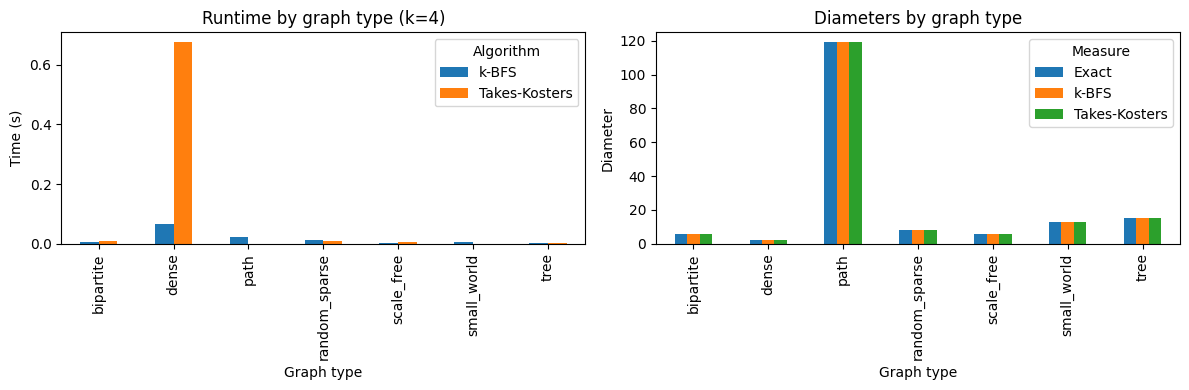

,graph_type,nodes,edges,density,exact_diameter,k_bfs_diameter,tk_diameter,k_bfs_abs_error,tk_abs_error,k_bfs_time,tk_time,k_bfs_peak_mb,tk_peak_mb
4,bipartite,120,374,0.052381,6,6,6,0,0,0.004957,0.008383,0.007790,0.005203
1,dense,120,4268,0.597759,2,2,2,0,0,0.066270,0.674614,0.008472,0.005089
5,path,120,119,0.016667,119,119,119,0,0,0.021710,0.000238,0.006996,0.005081
0,random_sparse,120,191,0.026751,8,8,8,0,0,0.011164,0.010111,0.009189,0.005333
3,scale_free,120,237,0.033193,6,6,6,0,0,0.003142,0.004098,0.007889,0.005203
2,small_world,120,240,0.033613,13,13,13,0,0,0.005250,0.000676,0.007355,0.005089
6,tree,120,119,0.016667,15,15,15,0,0,0.003906,0.000888,0.007423,0.005112


In [24]:
plot_df = core_table.set_index("graph_type")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_df[["k_bfs_time", "tk_time"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Runtime by graph type (k=4)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlabel("Graph type")
axes[0].legend(["k-BFS", "Takes-Kosters"], title="Algorithm")

plot_df[["exact_diameter", "k_bfs_diameter", "tk_diameter"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("Diameters by graph type")
axes[1].set_ylabel("Diameter")
axes[1].set_xlabel("Graph type")
axes[1].legend(["Exact", "k-BFS", "Takes-Kosters"], title="Measure")

plt.tight_layout()
plt.show()

core_table

## Observations (fill after running)
- On sparse or tree-like graphs, k-BFS often runs faster but can under-estimate diameter when k is small.
- Takes-Kosters tends to be more accurate on graphs with larger diameters (trees, grids, paths), but may take more BFS passes.
- Dense and small-world graphs often have low diameter; both methods may match exact, making error bars near zero.
- Scale-free graphs can show k-BFS sensitivity to k because hub selection changes distance coverage.
- If the error plot is blank, it usually means the mean absolute error is 0 for that slice; try k=1 or larger graphs to expose differences.